In [1]:
# ==========================================
# 1. IMPORT LIBRARY
# ==========================================

import os
import zipfile
import shutil
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import callbacks, models, layers

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.utils.class_weight import compute_class_weight

print("="*50)
print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)
print("="*50)

TensorFlow Version : 2.20.0
NumPy Version      : 2.0.2


In [2]:
# ==========================================
# 2. REPRODUCIBILITY
# ==========================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# ==========================================
# 3. MOUNT DRIVE & SETUP PATH
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

# Ganti path ini sesuai lokasi file ZIP dataset sampah kamu di Google Drive
ZIP_PATH = "/content/drive/MyDrive/klasifikasi sampah/Garbage Classification.zip"

RAW_DIR = Path("/content/garbage_raw")
SPLIT_DIR = Path("/content/garbage_split")

print("Path ZIP dataset:", ZIP_PATH)

Mounted at /content/drive
Path ZIP dataset: /content/drive/MyDrive/klasifikasi sampah/Garbage Classification.zip


In [4]:
# ==========================================
# 4. DATA COLLECTION: EKSTRAKSI DATASET
# ==========================================
if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"File ZIP tidak ditemukan di path: {ZIP_PATH}")

if RAW_DIR.exists():
    shutil.rmtree(RAW_DIR)

RAW_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(RAW_DIR)

print("Dataset berhasil diekstrak ke:", RAW_DIR)

Dataset berhasil diekstrak ke: /content/garbage_raw


In [5]:
# ==========================================
# 5. AUTO-DETECT DATASET FOLDER & CLASSES
# ==========================================
# Deteksi folder yang berisi subfolder kelas sampah
candidate_folders = [f for f in RAW_DIR.rglob("*") if f.is_dir() and len(list(f.glob("*"))) > 0]

# Mencari folder utama yang menampung subfolder kelas
DATASET_DIR = None
for folder in candidate_folders:
    subfolders = [sub.name for sub in folder.iterdir() if sub.is_dir()]
    if len(subfolders) >= 6: # Memastikan menampung 6 kelas sampah
        DATASET_DIR = folder
        break

if DATASET_DIR is None:
    DATASET_DIR = RAW_DIR

class_names = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])
print("Folder Dataset Utama:", DATASET_DIR)
print(f"Kelas terdeteksi ({len(class_names)} kelas):", class_names)

Folder Dataset Utama: /content/garbage_raw/garbage classification/Garbage classification
Kelas terdeteksi (6 kelas): ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


Kelas 'cardboard': 403 gambar
Kelas 'glass': 501 gambar
Kelas 'metal': 410 gambar
Kelas 'paper': 594 gambar
Kelas 'plastic': 482 gambar
Kelas 'trash': 137 gambar


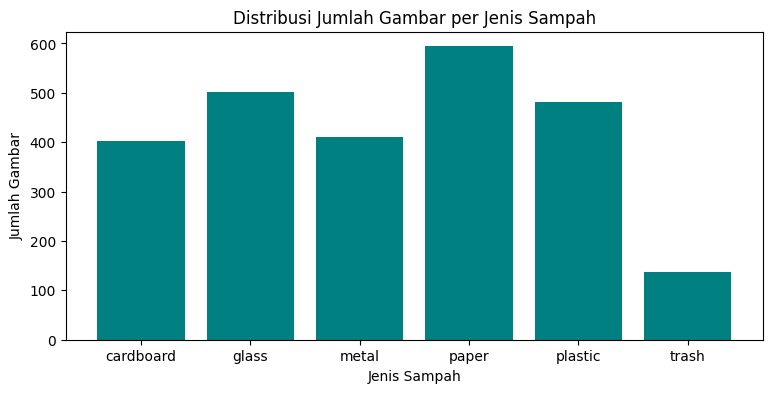

In [6]:
# ==========================================
# 6. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
class_counts = {}
for c in class_names:
    total = len(list((DATASET_DIR / c).glob("*.*")))
    class_counts[c] = total
    print(f"Kelas '{c}': {total} gambar")

# Visualisasi Distribusi Sampah
plt.figure(figsize=(9, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='teal')
plt.title("Distribusi Jumlah Gambar per Jenis Sampah")
plt.xlabel("Jenis Sampah")
plt.ylabel("Jumlah Gambar")
plt.show()

In [7]:
# ==========================================
# 7. DATA SPLITTING (TRAIN 80%, VAL 20%)
# ==========================================
!pip install split-folders -q
import splitfolders

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

# Membagi dataset menjadi Train (80%) dan Validation (20%)
splitfolders.ratio(
    DATASET_DIR,
    output=SPLIT_DIR,
    seed=SEED,
    ratio=(0.8, 0.2),
    group_prefix=None
)

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR = SPLIT_DIR / "val"
print("Pemisahan dataset selesai!")

Copying files: 2527 files [00:00, 7189.25 files/s]

Pemisahan dataset selesai!


In [8]:
# ==========================================
# 8. DATA AUGMENTATION & PIPELINE LOADER
# (VERSI DIPERBAIKI)
# ==========================================

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

mobilenet_preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

# ===========================
# TRAIN GENERATOR
# ===========================

train_datagen = ImageDataGenerator(

    preprocessing_function=mobilenet_preprocess,

    # Augmentasi ringan agar model tetap mengenali bentuk asli
    rotation_range=20,

    width_shift_range=0.15,
    height_shift_range=0.15,

    zoom_range=0.20,

    shear_range=0.15,

    horizontal_flip=True,

    # JANGAN gunakan vertical_flip
    # vertical_flip=False

    brightness_range=(0.8,1.2),

    fill_mode="nearest"

)

# ===========================
# VALIDATION GENERATOR
# ===========================

val_datagen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("="*60)
print("Class Mapping")
print(train_generator.class_indices)
print("="*60)

Found 2019 images belonging to 6 classes.
Found 508 images belonging to 6 classes.
Class Mapping
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [9]:
# ==========================================
# 9. TRANSFER LEARNING MOBILENETV2 (REVISI)
# ==========================================

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import models, layers

# ------------------------------------------
# Base Model
# ------------------------------------------
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

# Bekukan seluruh layer MobileNetV2
base_model.trainable = False

# ------------------------------------------
# Custom Classification Head
# ------------------------------------------
model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    # Membuat training lebih stabil
    layers.BatchNormalization(),

    # Hidden Layer
    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    # Output Layer
    layers.Dense(
        len(class_names),
        activation="softmax"
    )

])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,710 (10.01 MB)

 Trainable params: 364,166 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [10]:
# ==========================================
# 10. TRAINING MODEL (REVISI)
# ==========================================

from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Class Weight
# -----------------------------
classes = np.unique(train_generator.classes)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_generator.classes
)

class_weights = dict(enumerate(weights))

print("Class Weights")
print(class_weights)

# -----------------------------
# Compile Model
# -----------------------------
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),

    metrics=["accuracy"]

)

# -----------------------------
# Callbacks
# -----------------------------

early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=2,

    min_lr=1e-6,

    verbose=1

)

checkpoint = tf.keras.callbacks.ModelCheckpoint(

    "best_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

# -----------------------------
# Training
# -----------------------------

EPOCHS = 20

history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],

    class_weight=class_weights

)

Class Weights
{0: np.float64(1.045031055900621), 1: np.float64(0.84125), 2: np.float64(1.0259146341463414), 3: np.float64(0.708421052631579), 4: np.float64(0.874025974025974), 5: np.float64(3.0871559633027523)}
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.1911 - loss: 2.5948
Epoch 1: val_accuracy improved from None to 0.51378, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.2427 - loss: 2.3134 - val_accuracy: 0.5138 - val_loss: 1.4133 - learning_rate: 1.0000e-04
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.3697 - loss: 1.8074
Epoch 2: val_accuracy improved from 0.51378 to 0.62795, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 513ms/step - accuracy: 0.3933 - loss: 1.7471 - val_accuracy: 0.6280 - val_loss: 1.2189 - learning_rate: 1.0000e-04
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/st

In [11]:
# ==========================================
# 11. FINE TUNING (REVISI)
# ==========================================

# Membuka sebagian layer MobileNetV2
base_model.trainable = True

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Fine Tune mulai dari layer :", fine_tune_at)
print("Total layer :", len(base_model.layers))

# ---------------------------------

model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=1e-5

    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

# ---------------------------------

early_stop_ft = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1

)

reduce_lr_ft = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=2,

    min_lr=1e-7,

    verbose=1

)

# ---------------------------------

FINE_EPOCHS = 10

history_fine = model.fit(

    train_generator,

    validation_data=val_generator,

    initial_epoch=len(history.history["loss"]),

    epochs=len(history.history["loss"]) + FINE_EPOCHS,

    callbacks=[
        early_stop_ft,
        reduce_lr_ft
    ],

    class_weight=class_weights

)

Fine Tune mulai dari layer : 100
Total layer : 154
Epoch 21/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 79s 846ms/step - accuracy: 0.6186 - loss: 1.0288 - val_accuracy: 0.8287 - val_loss: 0.5706 - learning_rate: 1.0000e-05
Epoch 22/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 499ms/step - accuracy: 0.6578 - loss: 0.9480 - val_accuracy: 0.8287 - val_loss: 0.5608 - learning_rate: 1.0000e-05
Epoch 23/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 503ms/step - accuracy: 0.6786 - loss: 0.8708 - val_accuracy: 0.8228 - val_loss: 0.5565 - learning_rate: 1.0000e-05
Epoch 24/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 499ms/step - accuracy: 0.7023 - loss: 0.8148 - val_accuracy: 0.8248 - val_loss: 0.5545 - learning_rate: 1.0000e-05
Epoch 25/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 512ms/step - accuracy: 0.7182 - loss: 0.7931 - val_accuracy: 0.8189 - val_loss: 0.5505 - learning_rate: 1.0000e-05
Epoch 26/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 529ms/step - accuracy: 0.7078 - loss: 0.7823 - val_accuracy: 0.8209 - val_loss: 0.5484 - learning_rate: 1.0000e-05
E

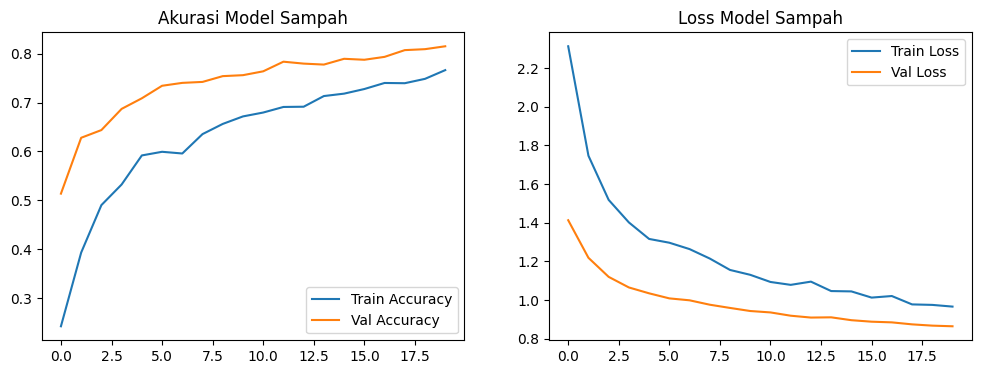

16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 382ms/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

   cardboard       0.91      0.86      0.89        81
       glass       0.85      0.71      0.77       101
       metal       0.77      0.82      0.79        82
       paper       0.90      0.83      0.86       119
     plastic       0.75      0.86      0.80        97
       trash       0.66      0.89      0.76        28

    accuracy                           0.82       508
   macro avg       0.81      0.83      0.81       508
weighted avg       0.83      0.82      0.82       508



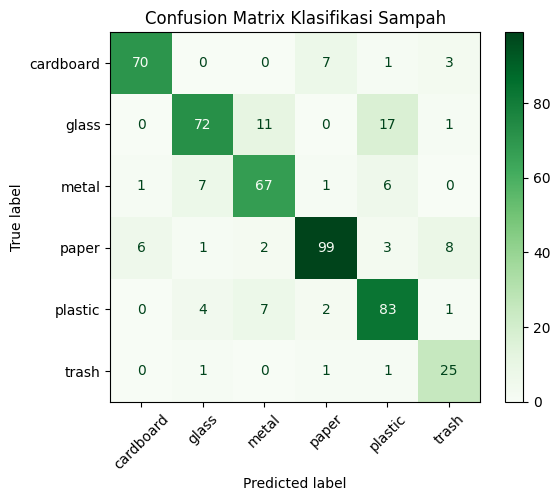

In [12]:
# ==========================================
# 12. EVALUASI MODEL
# ==========================================
# Visualisasi Kurva Latihan
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Akurasi Model Sampah')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Loss Model Sampah')
ax[1].legend()

plt.show()

# Evaluation Metrics
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Greens, xticks_rotation=45)
plt.title("Confusion Matrix Klasifikasi Sampah")
plt.show()


📤 Upload gambar sampah...


Saving pngtree-red-crumpled-aluminum-can-texture-png-image_15013539.png to pngtree-red-crumpled-aluminum-can-texture-png-image_15013539.png


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


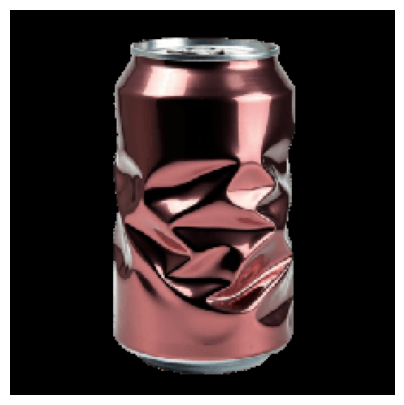

HASIL PREDIKSI
Kelas       : METAL
Confidence  : 67.98%
⚠️ Model masih kurang yakin.

🥫 LOGAM/KALENG: Sampah anorganik bernilai ekonomis tinggi. Bilas dan keringkan sebelum disetor.

Probabilitas Semua Kelas
----------------------------------------
cardboard   : 2.23%
glass       : 21.70%
metal       : 67.98%
paper       : 1.26%
plastic     : 1.84%
trash       : 5.00%

Prediksi gambar lain? (y/n): n

Terima kasih 😊


In [13]:
# ==========================================
# INFORMASI SETIAP KELAS
# ==========================================

from google.colab import files
from tensorflow.keras.preprocessing import image

GARBAGE_DETAILS = {
    'cardboard': '📦 KARDUS: Sampah anorganik daur ulang. Lipat hingga pipih dan jaga agar tetap kering.',
    'glass': '🍾 KACA: Sampah anorganik daur ulang. Bersihkan sisa isi dan pisahkan dari pecahan berbahaya.',
    'metal': '🥫 LOGAM/KALENG: Sampah anorganik bernilai ekonomis tinggi. Bilas dan keringkan sebelum disetor.',
    'paper': '📄 KERTAS: Sampah dapat didaur ulang. Pastikan tidak basah atau berminyak.',
    'plastic': '🥤 PLASTIK: Bilas lalu remukkan sebelum dibuang.',
    'trash': '🗑️ SAMPAH RESIDU: Sulit didaur ulang.'
}


# ==========================================
# FUNGSI PREDIKSI
# ==========================================

def predict_image(file_name):

    # Load gambar
    img = image.load_img(file_name, target_size=(224,224))

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    # Preprocessing
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    # Prediksi
    predictions = model.predict(img_array, verbose=0)

    pred_idx = np.argmax(predictions[0])
    confidence = predictions[0][pred_idx] * 100
    predicted_class = class_names[pred_idx]

    # Status
    if confidence < 70:
        status = "⚠️ Model masih kurang yakin."
    else:
        status = "✅ Model yakin."

    # Hasil
    print("="*60)
    print("HASIL PREDIKSI")
    print("="*60)

    print(f"Kelas       : {predicted_class.upper()}")
    print(f"Confidence  : {confidence:.2f}%")
    print(status)

    print()
    print(GARBAGE_DETAILS[predicted_class])

    print("\nProbabilitas Semua Kelas")
    print("-"*40)

    for label, prob in zip(class_names, predictions[0]):
        print(f"{label:12s}: {prob*100:.2f}%")

    print("="*60)


# ==========================================
# LOOP PREDIKSI
# ==========================================

while True:

    print("\n📤 Upload gambar sampah...")
    uploaded = files.upload()

    if len(uploaded) == 0:
        print("Tidak ada gambar yang dipilih.")
        break

    for file_name in uploaded.keys():
        predict_image(file_name)

    ulang = input("\nPrediksi gambar lain? (y/n): ").lower()

    if ulang != "y":
        print("\nTerima kasih 😊")
        break

In [15]:
# ==========================================
# 14. EXPORT MODEL SIKLUS MLLC
# ==========================================
model.save("model_garbage_mobilenetv2.h5")
print("Model klasifikasi sampah berhasil diekspor ke 'model_garbage_mobilenetv2.h5'!")

Model klasifikasi sampah berhasil diekspor ke 'model_garbage_mobilenetv2.h5'!
